In [ ]:
!pip install ultralytics

In [3]:
!pip install nn

  Preparing metadata (setup.py) ... done
  Created wheel for nn: filename=nn-0.1.1-py3-none-any.whl size=5705 sha256=90a1aa63c6abe84e07bf1aac3ee58143351bd0e99a4284fa32ad028297aed888
  Stored in directory: /root/.cache/pip/wheels/3f/e9/b6/b1df494bff610a11845b04550626402bb77cbd16f36a151467
Successfully built nn


In [4]:
!pip install DataLoader

  Preparing metadata (setup.py) ... done
  Created wheel for DataLoader: filename=dataloader-2.0-py3-none-any.whl size=10083 sha256=735f50dd425b2caa2a4e1eaa32485c7e49302b7b8252897f0d6b01e91d9d2888
  Stored in directory: /root/.cache/pip/wheels/fa/17/c3/e258aa863dd515a9b5759c01f4af55b2a2ea0881b2778fc749
Successfully built DataLoader


In [10]:
!pip install kaggle


In [11]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"katyahikiforova","key":"a3f01f2b10ca9f69e72427a4e6cb028e"}'}

In [12]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [15]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
!mkdir -p /content/drive/MyDrive/mlmlmlm/letters_raw
!mkdir -p /content/drive/MyDrive/mlmlmlm/letters_processed/train
!mkdir -p /content/drive/MyDrive/mlmlmlm/letters_processed/val
!mkdir -p /content/drive/MyDrive/mlmlmlm/models


In [18]:
!kaggle datasets download -d tatianasnwrt/russian-handwritten-letters -p /content/drive/MyDrive/mlmlmlm/letters_raw


Dataset URL: https://www.kaggle.com/datasets/tatianasnwrt/russian-handwritten-letters
License(s): other
 83% 91.0M/110M [00:00<00:00, 304MB/s]
100% 110M/110M [00:00<00:00, 296MB/s] 


In [19]:
!unzip /content/drive/MyDrive/mlmlmlm/letters_raw/russian-handwritten-letters.zip -d /content/drive/MyDrive/mlmlmlm/letters_raw/


Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: /content/drive/MyDrive/mlmlmlm/letters_raw/all_letters_image/all_letters_image/22_238.png  
  inflating: /content/drive/MyDrive/mlmlmlm/letters_raw/all_letters_image/all_letters_image/22_239.png  
  inflating: /content/drive/MyDrive/mlmlmlm/letters_raw/all_letters_image/all_letters_image/22_24.png  
  inflating: /content/drive/MyDrive/mlmlmlm/letters_raw/all_letters_image/all_letters_image/22_240.png  
  inflating: /content/drive/MyDrive/mlmlmlm/letters_raw/all_letters_image/all_letters_image/22_241.png  
  inflating: /content/drive/MyDrive/mlmlmlm/letters_raw/all_letters_image/all_letters_image/22_242.png  
  inflating: /content/drive/MyDrive/mlmlmlm/letters_raw/all_letters_image/all_letters_image/22_243.png  
  inflating: /content/drive/MyDrive/mlmlmlm/letters_raw/all_letters_image/all_letters_image/22_244.png  
  inflating: /content/drive/MyDrive/mlmlmlm/letters_raw/all_letters_image/all_letters_image/2

In [20]:
!mkdir -p /content/drive/MyDrive/mlmlmlm/letters_processed/train
!mkdir -p /content/drive/MyDrive/mlmlmlm/letters_processed/val


In [31]:
import os
import shutil
import random

SOURCE = "/content/drive/MyDrive/mlmlmlm/letters_raw/all_letters_image/all_letters_image"
TRAIN = "/content/drive/MyDrive/mlmlmlm/letters_processed/train"
VAL   = "/content/drive/MyDrive/mlmlmlm/letters_processed/val"

os.makedirs(TRAIN, exist_ok=True)
os.makedirs(VAL, exist_ok=True)

letters = [d for d in os.listdir(SOURCE) if os.path.isdir(os.path.join(SOURCE, d))]

for letter in letters:
    src = os.path.join(SOURCE, letter)
    imgs = [f for f in os.listdir(src) if os.path.isfile(os.path.join(src, f))]
    random.shuffle(imgs)

    split = int(len(imgs) * 0.8)
    train_imgs = imgs[:split]
    val_imgs = imgs[split:]

    os.makedirs(os.path.join(TRAIN, letter), exist_ok=True)
    os.makedirs(os.path.join(VAL, letter), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(src, img), os.path.join(TRAIN, letter, img))
    for img in val_imgs:
        shutil.copy(os.path.join(src, img), os.path.join(VAL, letter, img))

print("Данные распределены")


✅ Данные распределены и готовы для обучения


In [121]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [122]:
TRAIN_DIR = "/content/drive/MyDrive/mlmlmlm/letters_processed/train"
VAL_DIR   = "/content/drive/MyDrive/mlmlmlm/letters_processed/val"


In [123]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [124]:
num_classes = len(train_dataset.classes)

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)


In [125]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)


In [126]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        # Валидация
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Val Accuracy: {val_acc:.2f}%")


In [127]:
train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10)


Epoch [1/10], Loss: 0.6584, Val Accuracy: 94.94%
Epoch [2/10], Loss: 0.0981, Val Accuracy: 96.57%
Epoch [3/10], Loss: 0.0655, Val Accuracy: 94.20%
Epoch [4/10], Loss: 0.0392, Val Accuracy: 97.21%
Epoch [5/10], Loss: 0.0405, Val Accuracy: 95.83%
Epoch [6/10], Loss: 0.0412, Val Accuracy: 96.43%
Epoch [7/10], Loss: 0.0236, Val Accuracy: 96.85%
Epoch [8/10], Loss: 0.0193, Val Accuracy: 94.66%
Epoch [9/10], Loss: 0.0378, Val Accuracy: 96.82%
Epoch [10/10], Loss: 0.0131, Val Accuracy: 97.31%


In [131]:
SAVE_PATH = "/content/drive/MyDrive/mlmlmlm/models/best_cnn_model.pth"
torch.save(model.state_dict(), SAVE_PATH)
print(f"Модель сохранена в {SAVE_PATH}")


Модель сохранена в /content/drive/MyDrive/mlmlmlm/models/best_cnn_model.pth


In [129]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

val_acc = 100 * correct / total
print(f"Точность на валидации после сохранения: {val_acc:.2f}%")

Точность на валидации после сохранения: 97.31%


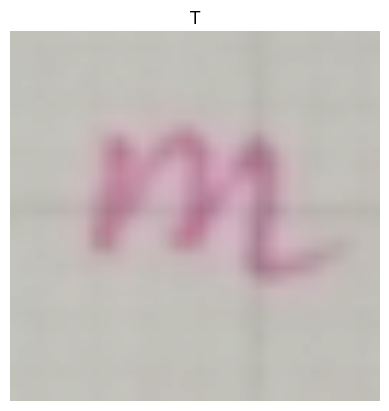

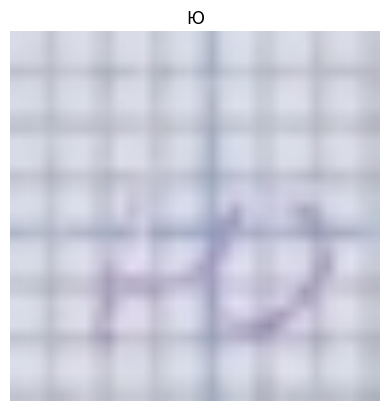

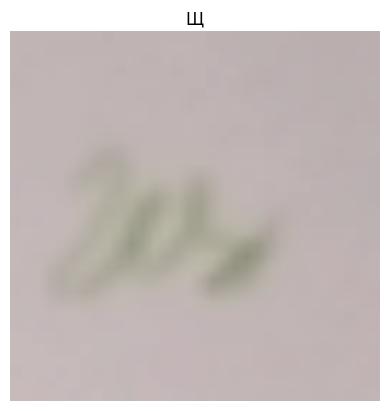

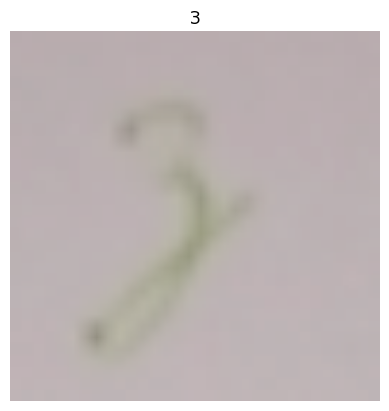

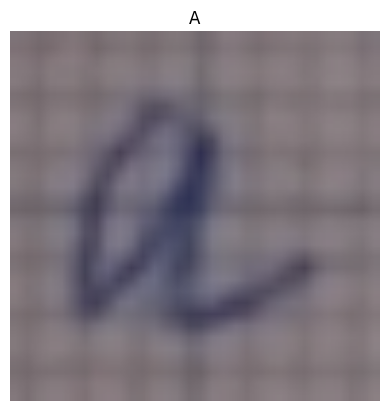

In [132]:
import matplotlib.pyplot as plt
import numpy as np

# Функция для отображения изображения
def imshow(img, title=""):
    img = img.numpy().transpose((1, 2, 0))  # CxHxW -> HxWxC
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # обратная нормализация
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Берём несколько батчей из train_loader
dataiter = iter(train_loader)
images, labels = next(dataiter)


for i in range(5):
    class_name = train_dataset.classes[labels[i]]
    imshow(images[i], title=class_name)


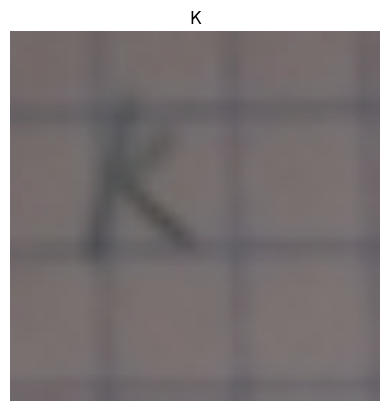

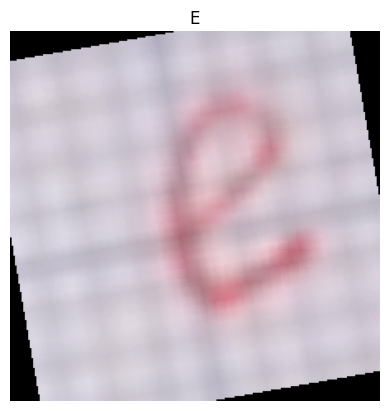

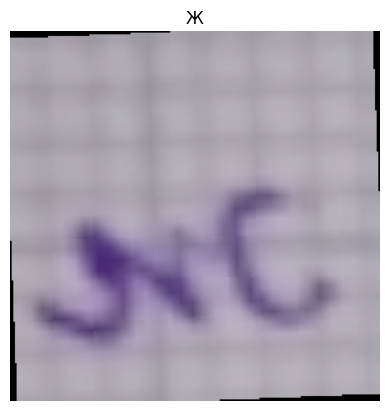

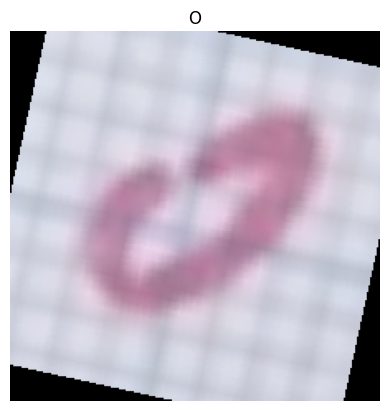

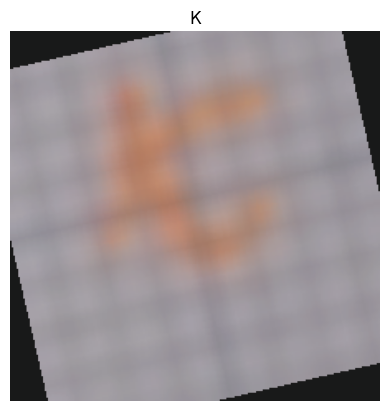

In [133]:
augment_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

aug_dataset = datasets.ImageFolder(TRAIN_DIR, transform=augment_transform)
aug_loader = DataLoader(aug_dataset, batch_size=5, shuffle=True)

# Покажем батч с аугментациями
dataiter = iter(aug_loader)
images, labels = next(dataiter)
for i in range(len(images)):
    class_name = train_dataset.classes[labels[i]]
    imshow(images[i], title=class_name)


In [134]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# --- Настройки ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

TRAIN_DIR = "/content/drive/MyDrive/mlmlmlm/letters_processed/train"
VAL_DIR   = "/content/drive/MyDrive/mlmlmlm/letters_processed/val"
SAVE_PATH = "/content/drive/MyDrive/mlmlmlm/models/best_resnet_model.pth"


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=transform)
val_dataset   = datasets.ImageFolder(VAL_DIR, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

num_classes = len(train_dataset.classes)
print("Классы:", train_dataset.classes)
print("Количество train изображений:", len(train_dataset))
print("Количество val изображений:", len(val_dataset))

# --- Модель ---
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)  # предобученные веса
model.fc = nn.Linear(model.fc.in_features, num_classes)          # заменяем последний слой
model = model.to(device)

# --- Потери и оптимизатор ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

# --- Загрузка предыдущих весов (если есть) ---
if os.path.exists(SAVE_PATH):
    model.load_state_dict(torch.load(SAVE_PATH))
    print("Загружены предыдущие веса модели")

# --- Функция обучения ---
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    best_acc = 0.0
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        # Валидация
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Val Accuracy: {val_acc:.2f}%")

        # Сохраняем лучшие веса
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), SAVE_PATH)
            print(f"Сохранены лучшие веса: {best_acc:.2f}%")

# --- Запуск обучения ---
train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10)


Device: cuda
Классы: ['А', 'Б', 'В', 'Г', 'Д', 'Е', 'Ё', 'Ж', 'З', 'И', 'Й', 'К', 'Л', 'М', 'Н', 'О', 'П', 'Р', 'С', 'Т', 'У', 'Ф', 'Х', 'Ц', 'Ч', 'Ш', 'Щ', 'Ъ', 'Ы', 'Ь', 'Э', 'Ю', 'Я']
Количество train изображений: 11362
Количество val изображений: 2828
Epoch [1/10], Loss: 0.6319, Val Accuracy: 93.78%
✅ Сохранены лучшие веса: 93.78%
Epoch [2/10], Loss: 0.1363, Val Accuracy: 91.83%
Epoch [3/10], Loss: 0.0970, Val Accuracy: 95.90%
✅ Сохранены лучшие веса: 95.90%
Epoch [4/10], Loss: 0.0610, Val Accuracy: 94.09%
Epoch [5/10], Loss: 0.0584, Val Accuracy: 95.83%
Epoch [6/10], Loss: 0.0722, Val Accuracy: 97.81%
✅ Сохранены лучшие веса: 97.81%
Epoch [7/10], Loss: 0.0408, Val Accuracy: 96.29%
Epoch [8/10], Loss: 0.0358, Val Accuracy: 96.96%
Epoch [9/10], Loss: 0.0543, Val Accuracy: 96.96%
Epoch [10/10], Loss: 0.0434, Val Accuracy: 97.07%


In [136]:
model.load_state_dict(torch.load("/content/drive/MyDrive/mlmlmlm/models/best_resnet_model.pth"))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

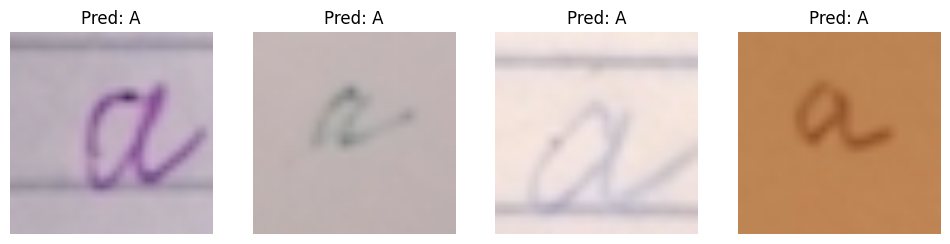

In [137]:
import matplotlib.pyplot as plt

model.eval()
images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, preds = torch.max(outputs, 1)


fig, axes = plt.subplots(1, 4, figsize=(12,3))
for i in range(4):
    ax = axes[i]
    img = images[i].cpu().permute(1,2,0)  # C,H,W → H,W,C
    img = img * torch.tensor([0.229,0.224,0.225]) + torch.tensor([0.485,0.456,0.406])  # денормализация
    img = img.numpy().clip(0,1)
    ax.imshow(img)
    ax.set_title(f"Pred: {train_dataset.classes[preds[i]]}")
    ax.axis('off')
plt.show()


In [138]:
!git config --global user.name "eqktrin"

In [139]:
!git clone https://github.com/alenchha/pp_summary_parser.git

Cloning into 'pp_summary_parser'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 72 (delta 14), reused 65 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 42.78 KiB | 6.11 MiB/s, done.
Resolving deltas: 100% (14/14), done.


In [140]:
%cd pp_summary_parser

/content/pp_summary_parser
